In [1]:
import numpy as np
from pyafv import FiniteVoronoiSimulator, PhysicalParams, visualize_2d
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
np.random.seed(42)

In [3]:
N = 1000
radius = 1.0
params = PhysicalParams(P0=6.2, r=radius, Lambda=0.6, delta=0)
box_size = np.sqrt(N * np.pi * radius**2 / 0.3)
pts = ((np.random.rand(N, 2) - 0.5) * 0.5) *  box_size      # shape (N,2)

In [4]:
sim = FiniteVoronoiSimulator(pts, params)

In [5]:
# Initial relaxation
dt = 0.01
for _ in tqdm(range(1000)):
    diag = sim.build()
    pts += diag["forces"] * dt
    sim.update_positions(pts)

  0%|          | 0/1000 [00:00<?, ?it/s]

(-25.0, 25.0)

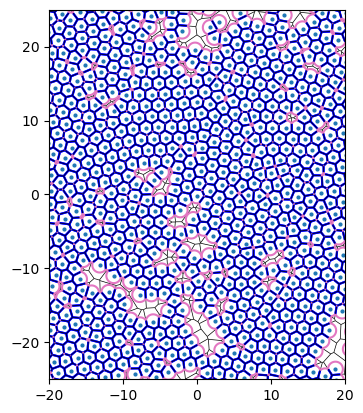

In [6]:
ax = sim.plot_2d()
FOV = 25
ax.set_xlim(-FOV*0.8, FOV*0.8)
ax.set_ylim(-FOV, FOV)

In [7]:
def custom_plot_2d(pts: np.ndarray, cell_colors, diag: dict, r: float, ax=None):
    """
    Custom plot function
    """
    if ax is None:
        ax = plt.gca()
    
    point_edges_type = diag["edges_type"]
    point_vertices_f_idx = diag["regions"]
    vertices_all = diag["vertices"]

    # Draw cell centers
    # ax.plot(pts[:, 0], pts[:, 1], 'o', color='gray', markersize=0.3, zorder=3)

    N = len(pts)

    alpha = 1.0

    # Draw each cell boundary
    for idx in range(N):
        edges_type = point_edges_type[idx]
        vertices_f_idx = point_vertices_f_idx[idx]

        x, y = pts[idx]
        fill_color = cell_colors[idx]

        if len(edges_type) < 2:
            angle = np.linspace(0, 2*np.pi, 100)
            ax.plot(x + r * np.cos(angle), y + r * np.sin(angle), color="lightgray", lw=1., zorder=1)
            ax.fill(x + r * np.cos(angle), y + r * np.sin(angle), color=fill_color, alpha=alpha, zorder=0)
            continue
        
        boundary_x = []
        boundary_y = []

        for idx_f, edge_type in enumerate(edges_type):
            v1_idx = vertices_f_idx[idx_f]
            x1, y1 = vertices_all[v1_idx]
            idx2 = idx_f + 1 if idx_f < len(edges_type)-1 else 0
            v2_idx = vertices_f_idx[idx2]
            x2, y2 = vertices_all[v2_idx]

            if edge_type == 1:
                ax.plot([x1, x2], [y1, y2], color="gray", lw=1., zorder=2)
                # ax.fill([x1, x2, x], [y1, y2, y], color=fill_color, alpha=alpha, zorder=0)
                boundary_x.append(x2)
                boundary_y.append(y2)
            else:
                angle1 = np.arctan2(y1-y, x1-x)
                angle2 = np.arctan2(y2-y, x2-x)
                dangle = np.linspace(0, (angle1 - angle2) % (2*np.pi), 100)

                if (angle1 - angle2) % (2*np.pi) > np.pi * 10./180:
                    ax.plot(x + r * np.cos(angle2+dangle), y + r * np.sin(angle2+dangle), color="lightgray", lw=1., zorder=3, solid_capstyle='butt')
                else:
                    ax.plot(x + r * np.cos(angle2+dangle), y + r * np.sin(angle2+dangle), color="gray", lw=1., zorder=3, solid_capstyle='butt')
                # ax.fill(np.append(x + r * np.cos(angle2+dangle), x), np.append(y + r * np.sin(angle2+dangle), y), color=fill_color, alpha=alpha, lw=0, zorder=0)
                boundary_x.extend(x + r * np.cos(angle2+dangle)[::-1])
                boundary_y.extend(y + r * np.sin(angle2+dangle)[::-1])

        ax.fill(boundary_x, boundary_y, color=fill_color, lw=0, alpha=alpha, zorder=0)

    ax.set_aspect("equal")
    return ax

In [8]:
base_colors = ["#9A9EC8", "#B69F80", "#728A75", "#A3B6BD"]
cell_colors = np.random.choice(base_colors, size=N)

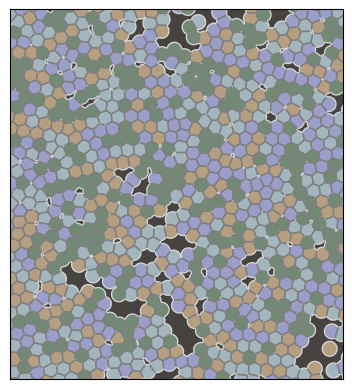

In [9]:
fig, ax = plt.subplots()

# ax = custom_plot_2d(pts, cell_colors, diag, r=radius)
visualize_2d(pts, diag, r=radius, ax=ax, 
             cell_colors=cell_colors, fill_alpha=1, 
             straight_colors="gray", arc_colors="lightgray",
             auto_adjust_bounds=False)

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)
ax.set_xlim(-FOV*0.9, FOV*0.9)
ax.set_facecolor('#474340')
ax.set_ylim(-FOV, FOV)

plt.savefig("test.png", bbox_inches='tight', dpi=300)